In [3]:
!pip install tensorflow

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    SimpleRNN,
    LSTM,
    GRU
)

In [33]:
data = pd.read_csv("monthly_milk_production.csv")
data.columns = ["Month", "Production"]
data["Month"] = pd.to_datetime(data["Month"])
data.set_index("Month", inplace=True)
data.head()

,Production
Month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [34]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


In [35]:
print(data.isnull().sum())

Production    0
dtype: int64


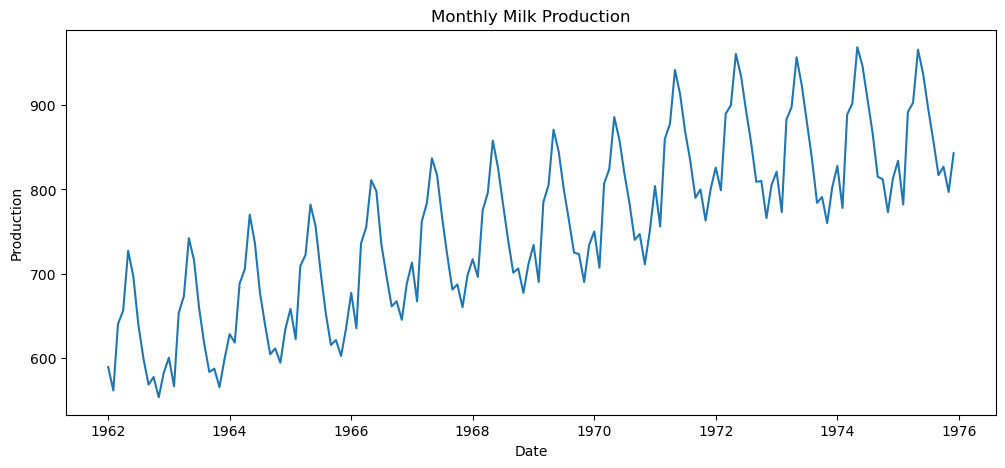

In [36]:
plt.figure(figsize=(12,5))
plt.plot(data["Production"])
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()

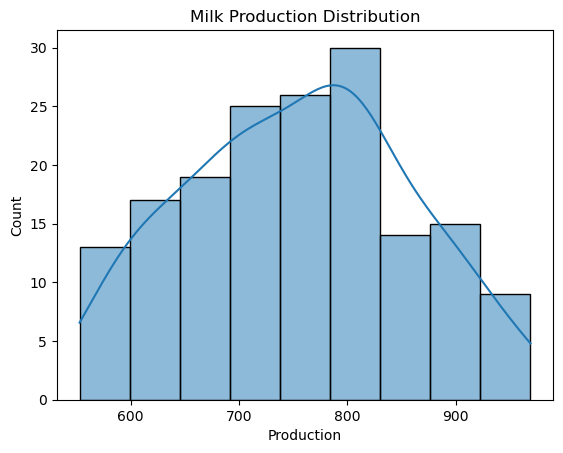

In [37]:
sns.histplot(data["Production"], kde=True)
plt.title("Milk Production Distribution")
plt.show()

In [38]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(
    data[["Production"]]
)

In [40]:
def create_seq(data, window=12):

    X = []
    y = []

    for i in range(len(data) - window):

        X.append(data[i:i+window])

        y.append(data[i+window])

    return np.array(X), np.array(y)
X, y = create_seq(scaled_data, 12)

In [41]:
split = int(len(X) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [42]:
print(X_train.shape)
print(X_test.shape)

(124, 12, 1)
(32, 12, 1)


In [43]:
model_rnn = Sequential()
model_rnn.add(
    SimpleRNN(
        50,
        activation='tanh',
        input_shape=(12,1)
    )
)

model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mse'
)
model_rnn.summary()

C:\Users\kfran\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.1221 - val_loss: 0.0253
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0310 - val_loss: 0.0830
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0195 - val_loss: 0.0113
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0095 - val_loss: 0.0076
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0064 - val_loss: 0.0136
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0046 - val_loss: 0.0054
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0043 - val_loss: 0.0071
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0039 - val_loss: 0.0051
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0036 - val_loss: 0.0050
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0035 - val_loss: 0.0047
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0035 - val_loss: 0.0046
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0034 - val_loss: 0.0041
E

In [46]:
model_lstm = Sequential()

model_lstm.add(
    LSTM(
        50,
        activation='tanh',
        input_shape=(12,1)
    )
)

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mse'
)
model_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.1786 - val_loss: 0.1950
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0535 - val_loss: 0.0264
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0334 - val_loss: 0.0324
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0288 - val_loss: 0.0330
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0269 - val_loss: 0.0368
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0264 - val_loss: 0.0269
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0251 - val_loss: 0.0260
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0248 - val_loss: 0.0279
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0244 - val_loss: 0.0272
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0239 - val_loss: 0.0249
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0237 - val_loss: 0.0247
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0232 - val_loss: 0.0264


In [48]:
model_gru = Sequential()

model_gru.add(
    GRU(
        50,
        activation='tanh',
        input_shape=(12,1)
    )
)

model_gru.add(Dense(1))

model_gru.compile(
    optimizer='adam',
    loss='mse'
)

model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.1127 - val_loss: 0.0945
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0308 - val_loss: 0.0208
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0279 - val_loss: 0.0205
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0227 - val_loss: 0.0246
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0206 - val_loss: 0.0310
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0204 - val_loss: 0.0251
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0194 - val_loss: 0.0202
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0188 - val_loss: 0.0199
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0181 - val_loss: 0.0219
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0180 - val_loss: 0.0207
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0174 - val_loss: 0.0196
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0169 - val_loss: 0.0172


In [50]:
def evaluate(model):

    pred = model.predict(X_test)

    pred = scaler.inverse_transform(pred)

    actual = scaler.inverse_transform(y_test)

    rmse = np.sqrt(
        mean_squared_error(actual, pred)
    )

    mae = mean_absolute_error(actual, pred)

    mape = np.mean(
        np.abs((actual - pred) / actual)
    ) * 100

    return rmse, mae, mape, pred, actual

In [51]:
rnn_res = evaluate(model_rnn)
print("RNN RMSE:", rnn_res[0])
print("RNN MAE:", rnn_res[1])
print("RNN MAPE:", rnn_res[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
RNN RMSE: 24.936176452429393
RNN MAE: 20.302770614624013
RNN MAPE: 2.3377569950042405


In [52]:
lstm_res = evaluate(model_lstm)
print("LSTM RMSE:", lstm_res[0])
print("LSTM MAE:", lstm_res[1])
print("LSTM MAPE:", lstm_res[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
LSTM RMSE: 58.30698914577849
LSTM MAE: 51.30892753601074
LSTM MAPE: 5.993480491695216


In [53]:
gru_res = evaluate(model_gru)
print("GRU RMSE:", gru_res[0])
print("GRU MAE:", gru_res[1])
print("GRU MAPE:", gru_res[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
GRU RMSE: 49.388186861890226
GRU MAE: 39.74658966064452
GRU MAPE: 4.555918669053721


In [54]:
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_res[0], lstm_res[0], gru_res[0]],
    'MAE': [rnn_res[1], lstm_res[1], gru_res[1]],
    'MAPE': [rnn_res[2], lstm_res[2], gru_res[2]]
})

print(results)

  Model       RMSE        MAE      MAPE
0   RNN  24.936176  20.302771  2.337757
1  LSTM  58.306989  51.308928  5.993480
2   GRU  49.388187  39.746590  4.555919


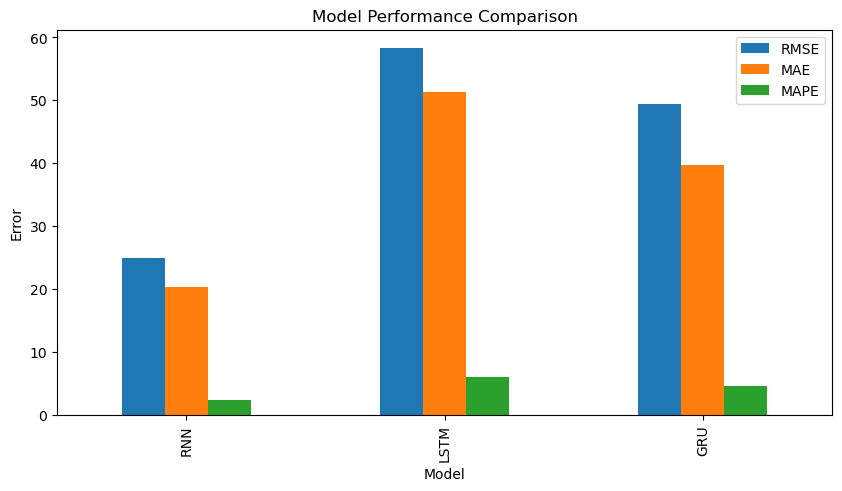

In [55]:
results.plot(
    x='Model',
    y=['RMSE', 'MAE', 'MAPE'],
    kind='bar',
    figsize=(10,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Error")

plt.show()

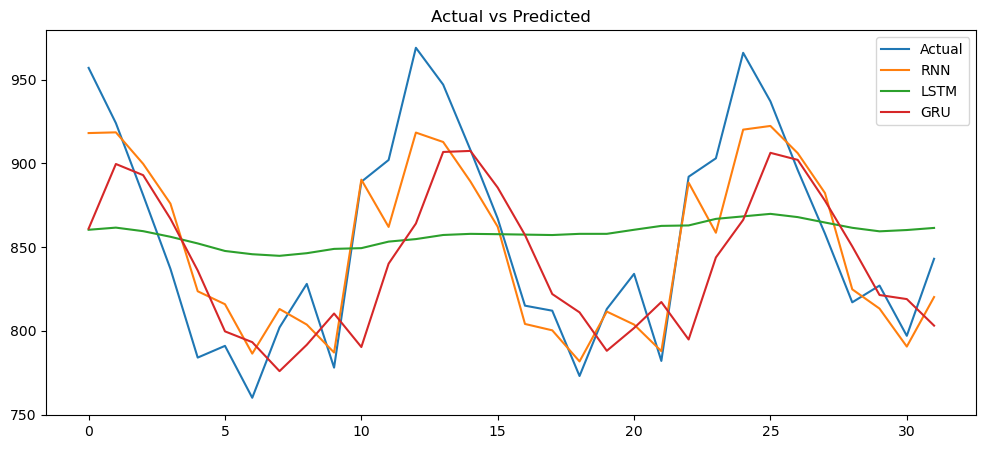

In [56]:
plt.figure(figsize=(12,5))
plt.plot(
    rnn_res[4],
    label="Actual"
)
plt.plot(
    rnn_res[3],
    label="RNN"
)
plt.plot(
    lstm_res[3],
    label="LSTM"
)
plt.plot(
    gru_res[3],
    label="GRU"
)

plt.title("Actual vs Predicted")

plt.legend()

plt.show()

In [57]:
def future_forecast(model, data, steps=12):

    temp = data[-12:].reshape(1,12,1)

    future = []

    for i in range(steps):

        pred = model.predict(temp)

        future.append(pred[0][0])

        temp = np.append(
            temp[:,1:,:],
            [[pred[0]]],
            axis=1
        )

    return scaler.inverse_transform(
        np.array(future).reshape(-1,1)
    )

In [58]:
future = future_forecast(
    model_lstm,
    scaled_data,
    12
)

print(future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[[865.5082 ]
 [869.6935 ]
 [877.71594]
 [877.4379 ]
 [875.63837]
 [868.32196]
 [862.3086 ]
 [859.02106]
 [858.64575]
 [861.7296 ]
 [864.5197 ]
 [870.0136 ]]


In [30]:
future_dates = pd.date_range(
    data.index[-1],
    periods=13,
    freq='ME'
)[1:]

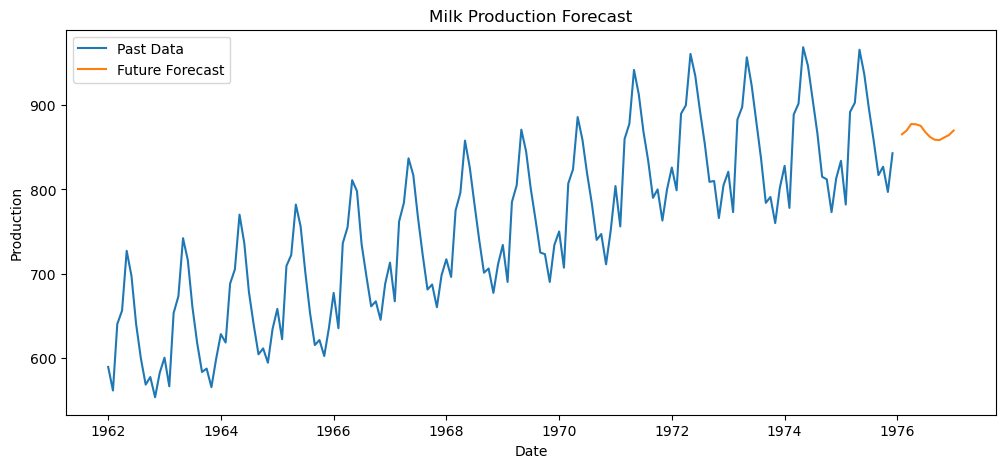

In [59]:
plt.figure(figsize=(12,5))

plt.plot(
    data.index,
    data["Production"],
    label="Past Data"
)

plt.plot(
    future_dates,
    future,
    label="Future Forecast"
)
plt.title("Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [60]:
# Business Insights

print("""
Business Insights:

1. Milk production shows clear seasonal trends.

2. Forecasting helps improve inventory
   and supply chain planning.

3. RNN, LSTM, and GRU models effectively
   capture time-series patterns.

4. LSTM and GRU models generally provide
   better forecasting for sequential data.

5. Future forecasting helps businesses:
   - reduce waste
   - optimize inventory
   - improve workforce planning
   - make strategic production decisions
""")


Business Insights:

1. Milk production shows clear seasonal trends.

2. Forecasting helps improve inventory
   and supply chain planning.

3. RNN, LSTM, and GRU models effectively
   capture time-series patterns.

4. LSTM and GRU models generally provide
   better forecasting for sequential data.

5. Future forecasting helps businesses:
   - reduce waste
   - optimize inventory
   - improve workforce planning
   - make strategic production decisions



In [61]:
# Conclusion

print("""
Conclusion:

1. Deep learning models were successfully
   implemented for milk production forecasting.

2. RNN, LSTM, and GRU models captured
   historical production patterns effectively.

3. Forecasting future milk production supports
   better operational and strategic planning.

4. Among the models tested, RNN achieved
   the lowest RMSE in this implementation.

5. Time-series forecasting can help dairy
   businesses improve efficiency and meet demand.
""")


Conclusion:

1. Deep learning models were successfully
   implemented for milk production forecasting.

2. RNN, LSTM, and GRU models captured
   historical production patterns effectively.

3. Forecasting future milk production supports
   better operational and strategic planning.

4. Among the models tested, RNN achieved
   the lowest RMSE in this implementation.

5. Time-series forecasting can help dairy
   businesses improve efficiency and meet demand.

